In [3]:
from sklearn.datasets import make_regression
import numpy as np

In [4]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1,n_targets=1, noise=80,random_state=15)

In [5]:
X.shape

(100, 1)

In [6]:
y.shape

(100,)

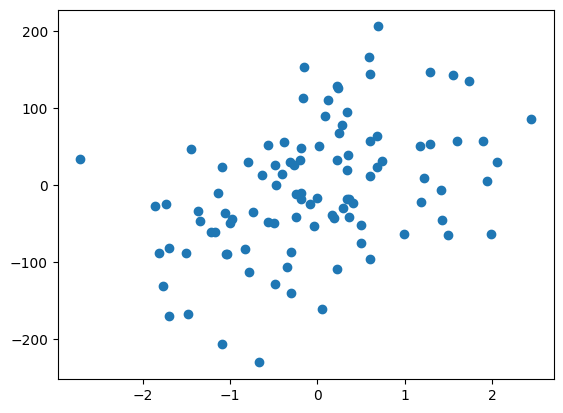

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

# Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
reg = LinearRegression()
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
reg.coef_

array([34.55481422])

In [11]:
reg.intercept_

np.float64(-5.256826493170236)

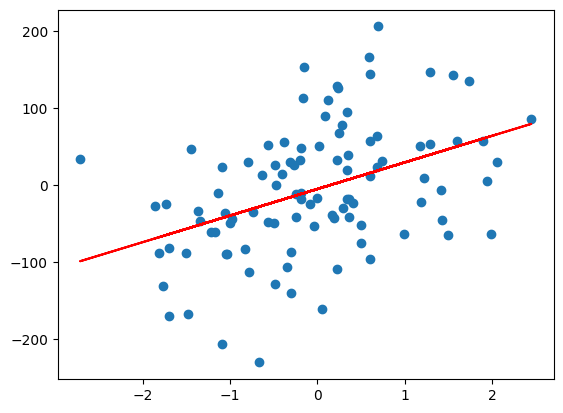

In [12]:
plt.scatter(X,y)
plt.plot(X , reg.predict(X) , color = "red")

In [13]:
 m = 70

In [14]:
b = 50

In [15]:
#70x + b

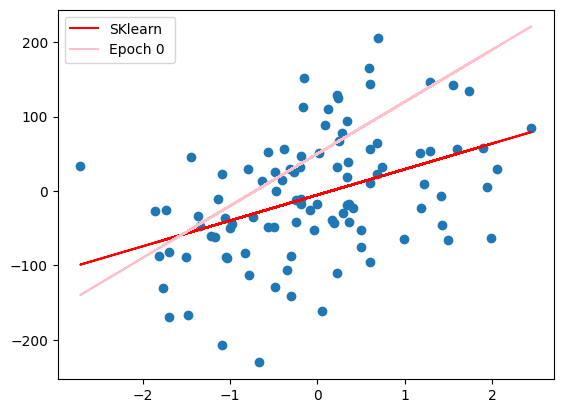

In [16]:
plt.scatter(X,y)
plt.plot(X , reg.predict(X) , color = "red", label="SKlearn")
plt.plot(X, X.reshape(X.shape[0]) * m + b , color="pink" , label = "Epoch 0 ")
plt.legend()

In [17]:
learning_rate = 0.01
b

50

In [18]:
np.sum((y - m * X.reshape(X.shape[0]) - b))

np.float64(-5365.370004564259)

In [19]:
m_der = -2 * np.sum((y - m * X.reshape(X.shape[0]) - b))
mold = m
m = m - learning_rate * m_der
b

50

In [20]:
b_der = -2 * np.sum((y - m * X.reshape(X.shape[0]) - b))
bold = b
b = b - learning_rate * b_der

In [21]:
m

np.float64(-37.30740009128519)

In [22]:
b

np.float64(-67.01406841835824)

In [23]:
b_der

np.float64(11701.406841835824)

In [24]:
learning_rate

0.01

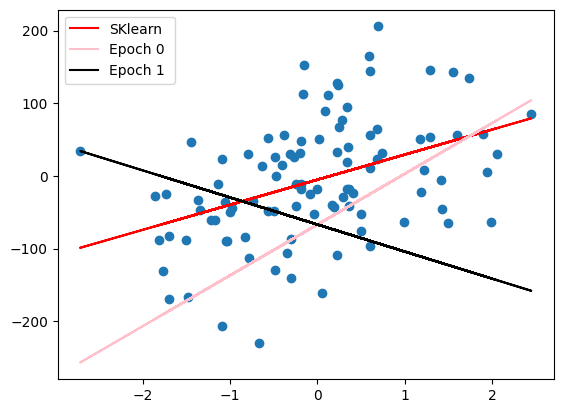

In [25]:
plt.scatter(X,y)
plt.plot(X , reg.predict(X) , color = "red", label="SKlearn")
plt.plot(X, X.reshape(X.shape[0]) * mold + b , color="pink" , label = "Epoch 0 ")
plt.plot(X, X.reshape(X.shape[0]) * m + b , color="black" , label = "Epoch 1 ")
plt.legend()

# Our own class

In [39]:
class GradientDescent:
    def __init__(self, learning_rate, epochs):
        self.m = 100
        self.b = -80
        self.lr = learning_rate
        self.epochs =  epochs

    def fit(self, X, y):
        plt.scatter(X,y)
        for i in range(self.epochs):
            b_der = -2 * np.sum((y - self.m * X.reshape(X.shape[0]) - self.b ))
            m_der = -2 * np.sum( (y - self.m * X.reshape(X.shape[0]) - self.b ) * X.reshape(X.shape[0]))

            self.b = self.b - self.lr * b_der
            self.m = self.m  - self.lr * m_der
            plt.plot(X, self.m * X.reshape(X.shape[0]) + self.b , color = "red")
        print(self.m , self.b)

    def predict(self, X):
        return self.m * X.reshape(X.shape[0]) + self.b

In [27]:
 (y - 70 * X.reshape(X.shape[0]) - 50 )

array([ 5.28386991e+01, -2.49558995e+01, -2.96208814e+01, -1.55388436e+02,
       -1.80302701e+02,  3.30512329e+01, -7.36496698e+01, -7.57026104e+01,
        9.74890945e+01, -1.05595733e+02,  1.73383009e+02, -1.58356138e+01,
       -1.80656329e+02, -3.50456300e+01, -9.97768343e+01, -7.42523934e-02,
       -2.20012645e+02, -2.55417916e+01,  7.50871743e+00, -1.05809493e+02,
       -1.01381137e+02, -3.34926916e+01, -1.01796600e+02, -2.52086547e+02,
       -6.59721419e+01, -5.85586031e+01,  1.21630456e+01, -6.70658305e+01,
       -6.88215665e+01, -1.00167715e+02,  6.23647141e+00, -5.75424110e+01,
       -9.21545302e+01,  7.43432832e+01, -4.93883695e+00, -1.88007290e+02,
       -8.08956098e+01,  1.07279146e+01, -3.31497471e+01, -7.00574063e+00,
       -8.71668254e+01, -7.47193301e+01, -1.25022265e+02,  3.32735313e+01,
       -1.60680947e+02, -1.95250005e+02,  7.36949540e+01, -1.16065959e+02,
       -1.37692448e+02, -1.44808492e+02, -4.23395393e+00,  1.13363997e+02,
       -1.26340215e+02,  

In [28]:
 np.sum(y - 70 * X.reshape(X.shape[0]) - 50 )

np.float64(-5365.370004564259)

In [29]:
 np.sum(y - 70 * X.reshape(X.shape[0]) - 50 ) / X.shape[0]

np.float64(-53.65370004564259)

In [40]:
gd = GradientDescent(learning_rate= 0.05, epochs=150)

6.040421657714084e+149 -4.019736219952825e+149


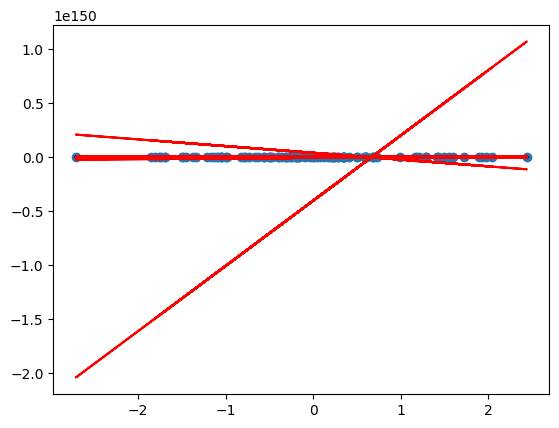

In [41]:
gd.fit(X,y)

In [32]:
y_pred = gd.predict(X)

In [33]:
from sklearn.metrics import r2_score

In [34]:
r2_score(y, y_pred)

-8.091102905326879e+295

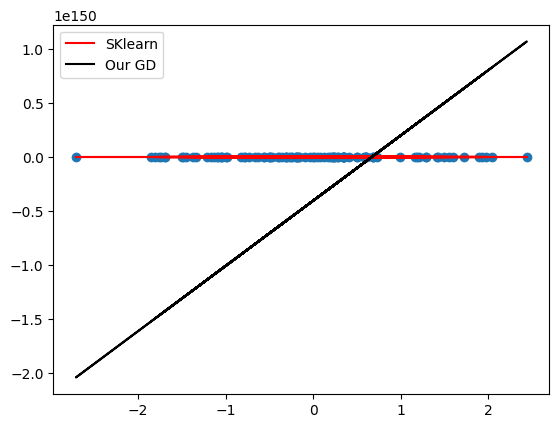

In [35]:
plt.scatter(X,y)
plt.plot(X , reg.predict(X) , color = "red", label="SKlearn")
plt.plot(X,y_pred , color="black" , label = "Our GD")
plt.legend()

# Our Gradient Descent Class for MLR